In [7]:
import numpy as np
import random

GRID_ROWS = 5
GRID_COLS = 5

environment = np.array([
    [ 0,  0,  0,  0,  0],
    [ 0, -1,  0,  0,  0],
    [ 0,  0,  0, -1,  0],
    [ 0,  0,  0,  0,  0],
    [ 0, -1,  0,  0,  1]
])

START_STATE = (0, 0)
GOAL_STATE = (GRID_ROWS - 1, GRID_COLS - 1)

ACTIONS = {
    'UP': (-1, 0),
    'DOWN': (1, 0),
    'LEFT': (0, -1),
    'RIGHT': (0, 1)
}
ACTION_NAMES = list(ACTIONS.keys())

LEARNING_RATE = 0.1
DISCOUNT_FACTOR = 0.9
EXPLORATION_RATE = 0.2
EPISODES = 10000
MAX_STEPS_PER_EPISODE = 2500

q_table = np.zeros((GRID_ROWS, GRID_COLS, len(ACTIONS)))


In [8]:
def choose_action(state, exploration_rate):
    if random.uniform(0, 1) < exploration_rate:
        return random.randint(0, len(ACTIONS) - 1)
    else:
        return np.argmax(q_table[state])

def get_next_state_and_reward(current_state, action_index):
    action_name = ACTION_NAMES[action_index]
    row_change, col_change = ACTIONS[action_name]

    new_row = current_state[0] + row_change
    new_col = current_state[1] + col_change

    if not (0 <= new_row < GRID_ROWS and 0 <= new_col < GRID_COLS):
        return current_state, -10

    next_state = (new_row, new_col)
    reward = environment[new_row, new_col]

    return next_state, reward

for episode in range(EPISODES):
    current_state = START_STATE
    done = False
    steps = 0

    while not done and steps < MAX_STEPS_PER_EPISODE:
        action_index = choose_action(current_state, EXPLORATION_RATE)
        next_state, reward = get_next_state_and_reward(current_state, action_index)

        old_q_value = q_table[current_state[0], current_state[1], action_index]
        max_future_q = np.max(q_table[next_state[0], next_state[1]])

        new_q_value = old_q_value + LEARNING_RATE * (reward + DISCOUNT_FACTOR * max_future_q - old_q_value)
        q_table[current_state[0], current_state[1], action_index] = new_q_value

        current_state = next_state
        steps += 1

        if current_state == GOAL_STATE:
            done = True


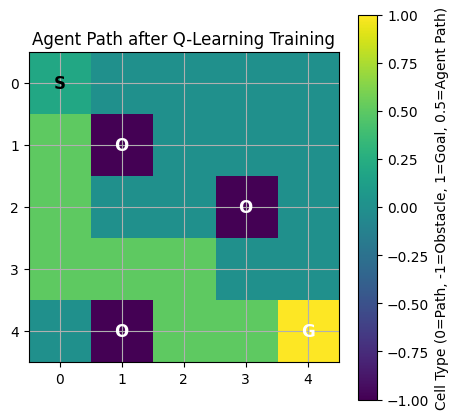

In [9]:
current_state = START_STATE
path = [current_state]
total_reward = 0
steps_taken = 0

while current_state != GOAL_STATE and steps_taken < MAX_STEPS_PER_EPISODE:
    action_index = np.argmax(q_table[current_state[0], current_state[1]])
    action_name = ACTION_NAMES[action_index]

    next_state, reward = get_next_state_and_reward(current_state, action_index)

    current_state = next_state
    total_reward += reward
    path.append(current_state)
    steps_taken += 1

    if steps_taken >= MAX_STEPS_PER_EPISODE:
        break

path_grid = np.copy(environment).astype(float)
for r, c in path:
    path_grid[r, c] = 0.5

path_grid[START_STATE] = 0.2
path_grid[GOAL_STATE] = 1.0

plt.figure(figsize=(GRID_COLS, GRID_ROWS))
plt.imshow(path_grid, cmap='viridis', origin='upper')
plt.colorbar(label='Cell Type (0=Path, -1=Obstacle, 1=Goal, 0.5=Agent Path)')
plt.title('Agent Path after Q-Learning Training')
plt.xticks(np.arange(GRID_COLS))
plt.yticks(np.arange(GRID_ROWS))
plt.grid(True)

for r in range(GRID_ROWS):
    for c in range(GRID_COLS):
        if (r, c) == START_STATE:
            plt.text(c, r, 'S', ha='center', va='center', color='black', fontsize=12, fontweight='bold')
        elif (r, c) == GOAL_STATE:
            plt.text(c, r, 'G', ha='center', va='center', color='white', fontsize=12, fontweight='bold')
        elif environment[r, c] == -1:
            plt.text(c, r, 'O', ha='center', va='center', color='white', fontsize=12, fontweight='bold')

plt.show()
